# 🔩 Classification de Défauts de Surface — NEU Surface Defect Database

**Auteur :** *HACHEMI Dyhia*  
**Module :** Deep Learning — Contrôle Qualité par Vision Artificielle  
**Date :** Avril 2026  

---

## 🎯 Objectif du projet

Ce projet applique le Deep Learning à un problème réel de **contrôle qualité industriel** :
détecter et classifier automatiquement les défauts de surface sur des aciers laminés à chaud.

Nous allons comparer **deux approches** :
- **Approche A** — CNN entraîné from scratch
- **Approche B** — Transfer Learning avec MobileNetV2 (pré-entraîné sur ImageNet)

---

## 📂 Dataset : NEU Surface Defect Database

Le dataset contient **1 800 images** (200×200 px, niveaux de gris) réparties en **6 classes** :

| Classe | Description |
|--------|-------------|
| `crazing` | Craquelures en réseau |
| `inclusion` | Impuretés incrustées |
| `patches` | Taches irrégulières |
| `pitted_surface` | Piqûres de surface |
| `rolled-in_scale` | Écailles laminées |
| `scratches` | Rayures linéaires |

> **Source :** [Kaggle — NEU Surface Defect Database](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database)

---

## 🗂️ Structure du notebook

1. **Installation & Imports** — Mise en place de l'environnement
2. **Téléchargement du Dataset** — Via l'API Kaggle
3. **Exploration des Données (EDA)** — Distribution, visualisation des images
4. **Préparation des Données** — Générateurs avec augmentation
5. *(Jour 2)* **Modèles** — CNN Custom + Transfer Learning MobileNetV2
6. *(Jour 3)* **Évaluation** — Courbes, matrices de confusion, comparatif
7. *(Jour 3)* **Démo Gradio** — Interface de prédiction interactive


## Section 1 — Installation & Imports

In [19]:
# Installation des bibliothèques nécessaires
!pip install gradio kaggle opendatasets tensorflow matplotlib seaborn scikit-learn --quiet
print("Bibliothèques installées avec succès !")

Bibliothèques installées avec succès !


In [20]:
import os # Bibliotheque pour le Système & fichiers
# Bibliotheques pour la Visualisation
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np # Bibliotheque pour la Manipulation de données
import opendatasets as od # Bibliotheque pour le Téléchargement du dataset
# Bibliotheques pour le deep learning
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Bibliotheque pour l'évaluation
from sklearn.metrics import classification_report, confusion_matrix
# Vérification du GPU
print("TensorFlow version :", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU disponible : {gpus[0].name}")
else:
    print("Aucun GPU détecté — l'entraînement sera plus lent (CPU)")

TensorFlow version : 2.19.0
GPU disponible : /physical_device:GPU:0


## Section 2 — Téléchargement du Dataset


In [21]:
# Téléchargement du dataset NEU depuis Kaggle
print("Téléchargement du dataset...")
NEU_dataset = od.download("https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database")
print("Dataset téléchargé !")

# Afficher la structure du dossier racine
print("\nContenu du dossier téléchargé :")
print(os.listdir("neu-surface-defect-database"))

Téléchargement du dataset...
Skipping, found downloaded files in "./neu-surface-defect-database" (use force=True to force download)
Dataset téléchargé !

Contenu du dossier téléchargé :
['NEU-DET']


In [31]:
# Vérification des 6 classes disponibles dans le jeu d'entraînement
TRAIN_PATH = "neu-surface-defect-database/NEU-DET/train/images"
VAL_PATH   = "neu-surface-defect-database/NEU-DET/validation/images"

classes = sorted(os.listdir(TRAIN_PATH))
print(f"Nombre de classes : {len(classes)}")
print(f"Classes : {classes}")

Nombre de classes : 6
Classes : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


# Section 3 — Explorer les données (EDA)
### Compter le nombre d'images dans chaque classe

In [25]:
print(f"Distribution des images — Jeu d'entraînement\n")

nombres_images = []
for classe in classes:
    class_path = os.path.join(TRAIN_PATH, classe)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    n = len(images)
    nombres_images.append(n)
    print(f"  {classe:<20} : {n} images")

print(f"\nTotal : {sum(nombres_images)} images | Moyenne : {sum(nombres_images)/len(nombres_images):.0f} images/classe")

Distribution des images — Jeu d'entraînement

  inclusion            : 240 images
  scratches            : 240 images
  patches              : 240 images
  pitted_surface       : 240 images
  crazing              : 240 images
  rolled-in_scale      : 240 images

Total : 1440 images | Moyenne : 240 images/classe


### Afficher la distribution des classes sous forme de graphique en barres

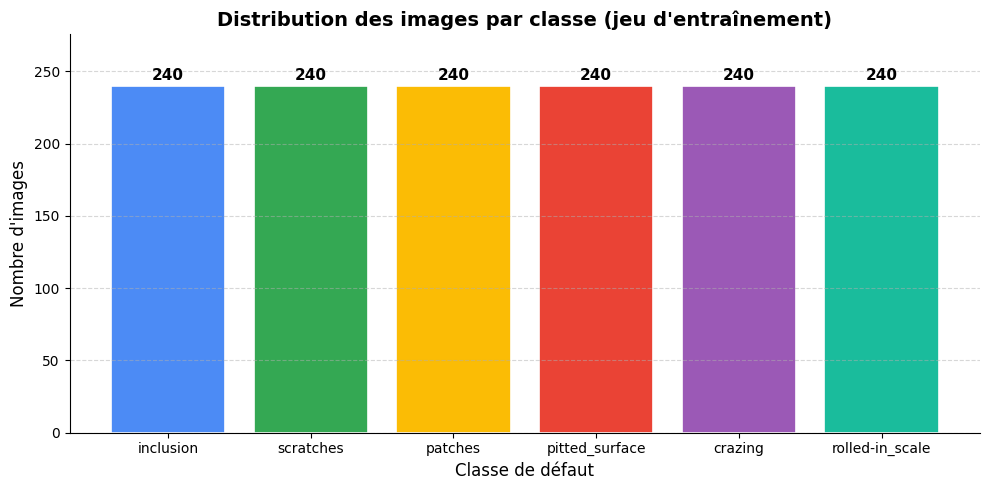

✅ Dataset parfaitement équilibré : 240 images par classe.


In [26]:
# ── Graphique de distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4C8BF5', '#34A853', '#FBBC05', '#EA4335', '#9B59B6', '#1ABC9C']
bars = ax.bar(classes, nombres_images, color=colors, edgecolor='white', linewidth=1.2)

# Étiquettes numériques au-dessus de chaque barre
for bar, n in zip(bars, nombres_images):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2, str(n),
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Classe de défaut', fontsize=12)
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.set_title('Distribution des images par classe (jeu d\'entraînement)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(nombres_images) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

print("Dataset parfaitement équilibré : 240 images par classe.")

### 🖼️ Affichage de quelques exemples d'images pour chaque classe

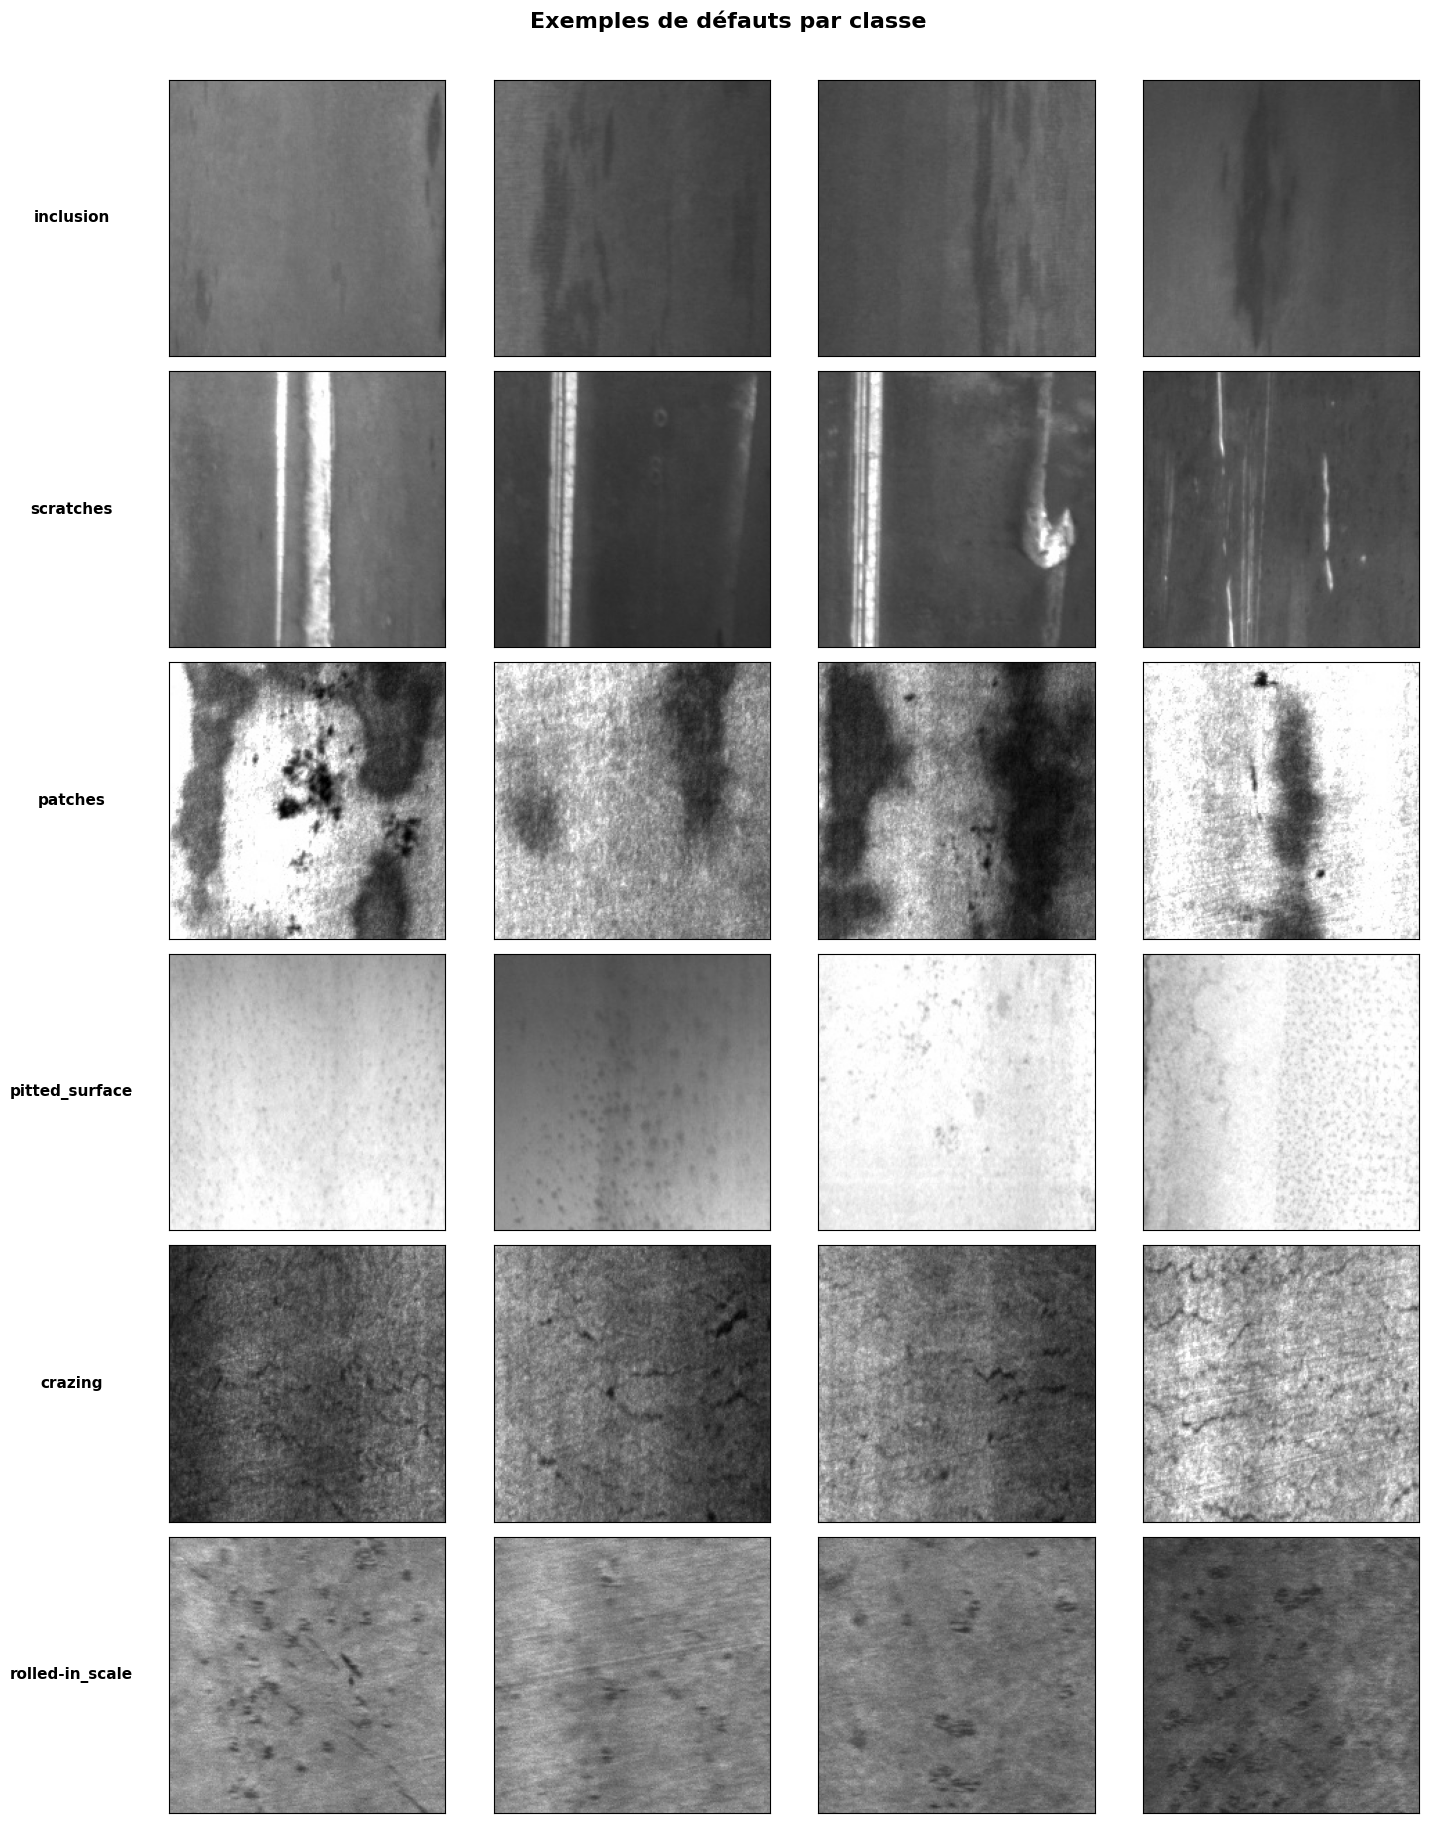

In [29]:
# ── Grille d'exemples : 4 images × 6 classes ─────────────────────────────────
N_SAMPLES = 4  # Nombre d'images à afficher par classe

fig, axes = plt.subplots(len(classes), N_SAMPLES,
                         figsize=(15, 3 * len(classes)))
fig.suptitle("Exemples de défauts par classe", fontsize=16, fontweight='bold', y=1.01)

for i, cls in enumerate(classes):
    folder_path = os.path.join(TRAIN_PATH, cls)
    img_names = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ][:N_SAMPLES]

    for j in range(N_SAMPLES):
        ax = axes[i, j]
        if j < len(img_names):
            img = Image.open(os.path.join(folder_path, img_names[j]))
            ax.imshow(img, cmap='gray')
            if j == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight='bold',
                              rotation=0, labelpad=70, va='center')
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 🔄 Section 4 — Préparation des Données

On utilise `ImageDataGenerator` de Keras pour :
1. **Normaliser** les pixels (valeurs ramenées dans [0, 1])
2. **Augmenter** les données d'entraînement (rotations, décalages, flip…)

> ⚠️ L'augmentation est appliquée **uniquement au jeu d'entraînement**.
> Le jeu de validation reçoit uniquement la normalisation.

In [33]:
# Hyperparamètres des générateurs
IMG_SIZE   = (224, 224)  # Taille cible des images
BATCH_SIZE = 32          # Nombre d'images traitées à chaque itération

# Générateur d'entraînement (avec augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Générateur de validation (normalisation uniquement)
val_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des images depuis les dossiers
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # One-hot encoding pour classification multi-classes
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Vérification
images_batch, labels_batch = next(train_generator)
print(f"Shape d'un batch d'images : {images_batch.shape}")
print(f"Shape des labels          : {labels_batch.shape}")
print(f"Correspondance classes    : {train_generator.class_indices}")

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Shape d'un batch d'images : (32, 224, 224, 3)
Shape des labels          : (32, 6)
Correspondance classes    : {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
